# Analyse des balayages lot × sous-ensemble, tous jeux

Les notebooks `<modèle>_sweep` entraînent six runs par jeu (lots 8, 16 et 32 ×
500 premières images ou tout le split, 600 itérations, init COCO) et les comparent
jeu par jeu. Ce notebook les compare **entre jeux** : quelle configuration gagne,
de façon constante ou non, et pourquoi (images vues, surapprentissage, dynamique et
composantes de la perte, classes apprises), puis l'écart aux poids publiés.

**Source.** Les sorties versionnées des balayages ([voc](voc/tiny-yolov3-voc_sweep.ipynb), [kitti](kitti/tiny-yolov3-kitti_sweep.ipynb), [visdrone](visdrone/tiny-yolov3-visdrone_sweep.ipynb), [flir](flir/tiny-yolov3-flir_sweep.ipynb), [exdark](exdark/tiny-yolov3-exdark_sweep.ipynb), [crowdhuman](crowdhuman/tiny-yolov3-crowdhuman_sweep.ipynb)) et des inférences des
poids publiés (`tiny-yolov3-coco_infer`, `tiny-yolov2-voc_infer`), relues par
`tools/notebooks/balayages.py` ; les figures viennent de
`tools/figures/balayages.py`. Rien n'est recalculé ni saisi à la main : un
balayage relancé et versionné se retrouve ici après `Run All`. Ni GPU ni données.
Les runs sans journal dans leur notebook (session Colab précédente) sont complétés
par leur `loss.csv` sous `build/notebooks/`, rapatrié du Drive par `make harvest`.

**Prudence.** Palier R : scores sur les **50 premières images** d'évaluation, non
publiables (règles de M12) ; une classe à une ou deux instances y saute de 0 à
100. **Score** = mAP@0,5 du jeu : mAP 11 points, sauf FLIR (métrique COCO) dont on
prend l'AP50 ; **score relatif** = score / meilleur run du jeu. Contexte et tables :
[resultats-balayages.md](../docs/tasks/resultats-balayages.md).

Généré par `python -m tools.notebooks` : modifier
`tools/notebooks/gabarits.py:analysis`, pas ce fichier.

## Paramètres

In [1]:
DATASETS = None  # jeux analysés (ex. ['voc', 'kitti']) ; None : tous les balayages exécutés
OUT      = 'build/notebooks/balayages'  # PNG et données (relatif à la racine du dépôt)
SMOOTH   = 25  # lissage des courbes de perte (itérations)

## Environnement

In [2]:
import os
import sys
from pathlib import Path

from IPython.display import Image, Markdown, display

CANDIDATES = (Path.cwd(), *Path.cwd().parents, Path("/content/EmbeddedComputervision"))
ROOT = next((d for d in CANDIDATES if (d / "tools" / "notebooks").is_dir()), None)
if ROOT is None:
    raise SystemExit(f"dépôt introuvable depuis {Path.cwd()}")
os.chdir(ROOT)
sys.path[:0] = [str(ROOT), str(ROOT / "python")]

from tools.figures import balayages as FB
from tools.notebooks import balayages as B

data, pending = B.load_all(datasets=DATASETS)
if not data:
    raise SystemExit("aucun balayage exécuté dans notebooks/*/*_sweep.ipynb")
OBS = B.observations(data)


def show(paths):
    for p in paths:
        display(Image(data=Path(p).read_bytes(), format="png"))


print(f"dépôt : {ROOT}")
for d in data.values():
    print(f"  {d['label']:10s} {len(d['runs'])} runs, {d['metric']}, révision {d['rev']}, "
          f"{d['notebook']}")
for ds, p in pending.items():
    print(f"  {ds:10s} pas encore exécuté ({p})")

dépôt : /home/leonard/Documents/Perso/EmbeddedComputervision
  VOC        6 runs, voc, révision 1a967f4, notebooks/voc/tiny-yolov3-voc_sweep.ipynb
  VisDrone   6 runs, voc, révision 1a967f4, notebooks/visdrone/tiny-yolov3-visdrone_sweep.ipynb
  KITTI      6 runs, voc, révision 1a967f4, notebooks/kitti/tiny-yolov3-kitti_sweep.ipynb
  FLIR       6 runs, coco, révision 4e47dbc, notebooks/flir/tiny-yolov3-flir_sweep.ipynb
  ExDark     6 runs, voc, révision 35e949b, notebooks/exdark/tiny-yolov3-exdark_sweep.ipynb
  CrowdHuman 6 runs, voc, révision 35e949b, notebooks/crowdhuman/tiny-yolov3-crowdhuman_sweep.ipynb


## Vue d'ensemble

Un jeu par ligne : meilleur et pire run, rapport entre les deux, plage des pertes
finales et meilleur poids publié. Puis tous les runs, du meilleur au moins bon
dans chaque jeu.

In [3]:
display(Markdown(B.summary_table(data)))
display(Markdown(B.runs_table(data)))

| jeu | images d'entr. | métrique | meilleur run | score | pire run | score | écart max/min | perte finale (min–max) | meilleur poids publié |
|---|---|---|---|---|---|---|---|---|---|
| VOC | 16551 | mAP 11 pts | **b32-sall** | **36,27** | b8-sall | 12,41 | ×2,9 | 11,9–18,3 | tiny-yolov3-coco 68,45 |
| VisDrone | 6471 | mAP 11 pts | **b32-sall** | **2,24** | b8-s500 | 0,56 | ×4,0 | 186,0–252,1 | tiny-yolov3-coco 6,95 |
| KITTI | 5985 | mAP 11 pts | **b32-sall** | **2,38** | b8-s500 | 0,49 | ×4,9 | 18,0–22,1 | tiny-yolov3-coco 20,55 |
| FLIR | 10742 | AP50 (COCO) | **b8-sall** | **2,90** | b8-s500 | 1,30 | ×2,2 | 52,2–67,3 | tiny-yolov3-coco 9,90 |
| ExDark | 3000 | mAP 11 pts | **b32-sall** | **13,29** | b8-s500 | 2,75 | ×4,8 | 13,1–28,1 | tiny-yolov3-coco 24,61 |
| CrowdHuman | 15000 | mAP 11 pts | **b16-sall** | **35,87** | b8-sall | 17,67 | ×2,0 | 44,8–67,2 | tiny-yolov3-coco 38,37 |

| jeu | run | lot | images | époques | perte finale | score | relatif | rang | durée (min) |
|---|---|---|---|---|---|---|---|---|---|
| VOC | b32-sall | 32 | tout | 1,16 | 14,66 | 36,27 | 1,00 | 1,0 | 10,4 |
| VOC | b16-sall | 16 | tout | 0,58 | 17,45 | 34,70 | 0,96 | 2,0 | 5,3 |
| VOC | b8-s500 | 8 | 500 | 9,60 | 18,00 | 30,14 | 0,83 | 3,0 | 2,9 |
| VOC | b16-s500 | 16 | 500 | 19,20 | 13,78 | 25,58 | 0,71 | 4,0 | 5,4 |
| VOC | b32-s500 | 32 | 500 | 38,40 | 11,95 | 24,01 | 0,66 | 5,0 | 10,7 |
| VOC | b8-sall | 8 | tout | 0,29 | 18,29 | 12,41 | 0,34 | 6,0 | 2,9 |
| VisDrone | b32-sall | 32 | tout | 2,97 | 185,96 | 2,24 | 1,00 | 1,0 | 11,5 |
| VisDrone | b16-s500 | 16 | 500 | 19,20 | 220,65 | 1,35 | 0,60 | 2,0 | 5,9 |
| VisDrone | b8-sall | 8 | tout | 0,74 | 208,68 | 1,24 | 0,55 | 3,0 | 2,9 |
| VisDrone | b16-sall | 16 | tout | 1,48 | 203,54 | 1,15 | 0,51 | 4,0 | 5,9 |
| VisDrone | b32-s500 | 32 | 500 | 38,40 | 200,33 | 0,78 | 0,35 | 5,0 | 12,5 |
| VisDrone | b8-s500 | 8 | 500 | 9,60 | 252,11 | 0,56 | 0,25 | 6,0 | 3,1 |
| KITTI | b32-sall | 32 | tout | 3,21 | 19,52 | 2,38 | 1,00 | 1,0 | 10,1 |
| KITTI | b16-sall | 16 | tout | 1,60 | 20,29 | 2,23 | 0,94 | 2,0 | 5,2 |
| KITTI | b8-sall | 8 | tout | 0,80 | 22,12 | 2,18 | 0,92 | 3,0 | 2,7 |
| KITTI | b32-s500 | 32 | 500 | 38,40 | 17,99 | 2,02 | 0,85 | 4,0 | 10,3 |
| KITTI | b16-s500 | 16 | 500 | 19,20 | 20,39 | 0,50 | 0,21 | 5,0 | 5,2 |
| KITTI | b8-s500 | 8 | 500 | 9,60 | 21,49 | 0,49 | 0,21 | 6,0 | 2,9 |
| FLIR | b8-sall | 8 | tout | 0,45 | 67,27 | 2,90 | 1,00 | 1,0 | 2,5 |
| FLIR | b16-sall | 16 | tout | 0,89 | 64,38 | 2,60 | 0,90 | 2,0 | 4,8 |
| FLIR | b32-sall | 32 | tout | 1,79 | 59,68 | 1,70 | 0,59 | 3,0 | 9,6 |
| FLIR | b16-s500 | 16 | 500 | 19,20 | 55,84 | 1,50 | 0,52 | 4,0 | 4,9 |
| FLIR | b32-s500 | 32 | 500 | 38,40 | 52,19 | 1,40 | 0,48 | 5,0 | 9,9 |
| FLIR | b8-s500 | 8 | 500 | 9,60 | 63,55 | 1,30 | 0,45 | 6,0 | 2,5 |
| ExDark | b32-sall | 32 | tout | 6,40 | 21,25 | 13,29 | 1,00 | 1,0 | 7,1 |
| ExDark | b32-s500 | 32 | 500 | 38,40 | 13,13 | 9,26 | 0,70 | 2,0 | 7,4 |
| ExDark | b8-sall | 8 | tout | 1,60 | 28,09 | 7,86 | 0,59 | 3,0 | 2,1 |
| ExDark | b16-sall | 16 | tout | 3,20 | 24,04 | 7,06 | 0,53 | 4,0 | 3,9 |
| ExDark | b16-s500 | 16 | 500 | 19,20 | 15,23 | 6,68 | 0,50 | 5,0 | 3,9 |
| ExDark | b8-s500 | 8 | 500 | 9,60 | 18,11 | 2,75 | 0,21 | 6,0 | 2,3 |
| CrowdHuman | b16-sall | 16 | tout | 0,64 | 54,77 | 35,87 | 1,00 | 1,0 | 4,1 |
| CrowdHuman | b32-sall | 32 | tout | 1,28 | 53,17 | 30,61 | 0,85 | 2,0 | 7,4 |
| CrowdHuman | b16-s500 | 16 | 500 | 19,20 | 49,17 | 27,81 | 0,78 | 3,0 | 4,2 |
| CrowdHuman | b32-s500 | 32 | 500 | 38,40 | 44,79 | 27,44 | 0,76 | 4,0 | 7,8 |
| CrowdHuman | b8-s500 | 8 | 500 | 9,60 | 52,35 | 27,06 | 0,75 | 5,0 | 2,3 |
| CrowdHuman | b8-sall | 8 | tout | 0,32 | 67,22 | 17,67 | 0,49 | 6,0 | 2,3 |

## 1. Grille lot × sous-ensemble, jeu par jeu

Chaque case est un run : son score, puis ce score en pourcentage du meilleur run du jeu (★). La couleur suit ce pourcentage, sur la même échelle pour tous les jeux : on compare la *forme* des grilles malgré des mAP qui vont de 2 à 36. Une colonne « tout » plus foncée que la colonne « 500 im. » veut dire que voir tout le split paie ; une ligne « lot 32 » plus foncée, qu'un grand lot paie.

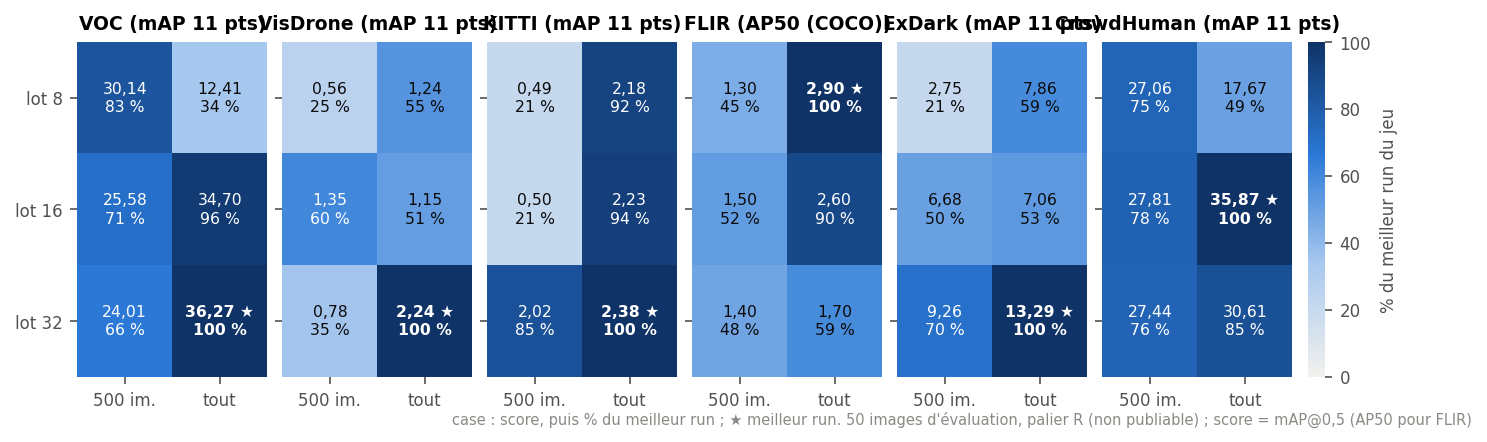

**Constat.** Sur 6 jeux, le score relatif moyen classe les runs ainsi : `b32-sall` 0,91, `b16-sall` 0,81, `b8-sall` 0,65, `b32-s500` 0,63, `b16-s500` 0,55, `b8-s500` 0,45. Meilleur run par jeu : VOC `b32-sall`, VisDrone `b32-sall`, KITTI `b32-sall`, FLIR `b8-sall`, ExDark `b32-sall`, CrowdHuman `b16-sall` (`b32-sall` gagne 4 fois sur 6).

In [4]:
show(FB.PLOTS['grilles'](data, OUT))
display(Markdown("**Constat.** " + OBS['grilles']))

## 2. Les jeux classent-ils les runs de la même façon ?

À gauche, le rang de chaque run dans chaque jeu (1 en haut) : une ligne plate en haut est un run toujours bon. Couleur : le lot (clair 8, foncé 32) ; trait plein : tout le split, tirets : 500 images. À droite, la corrélation de rangs de Spearman entre les classements de deux jeux : 1, même ordre ; 0, aucun lien. Avec 6 runs, il faut |ρ| ≥ 0,83 pour conclure à 5 % ; les mAP sur 50 images sont bruitées (règle M12).

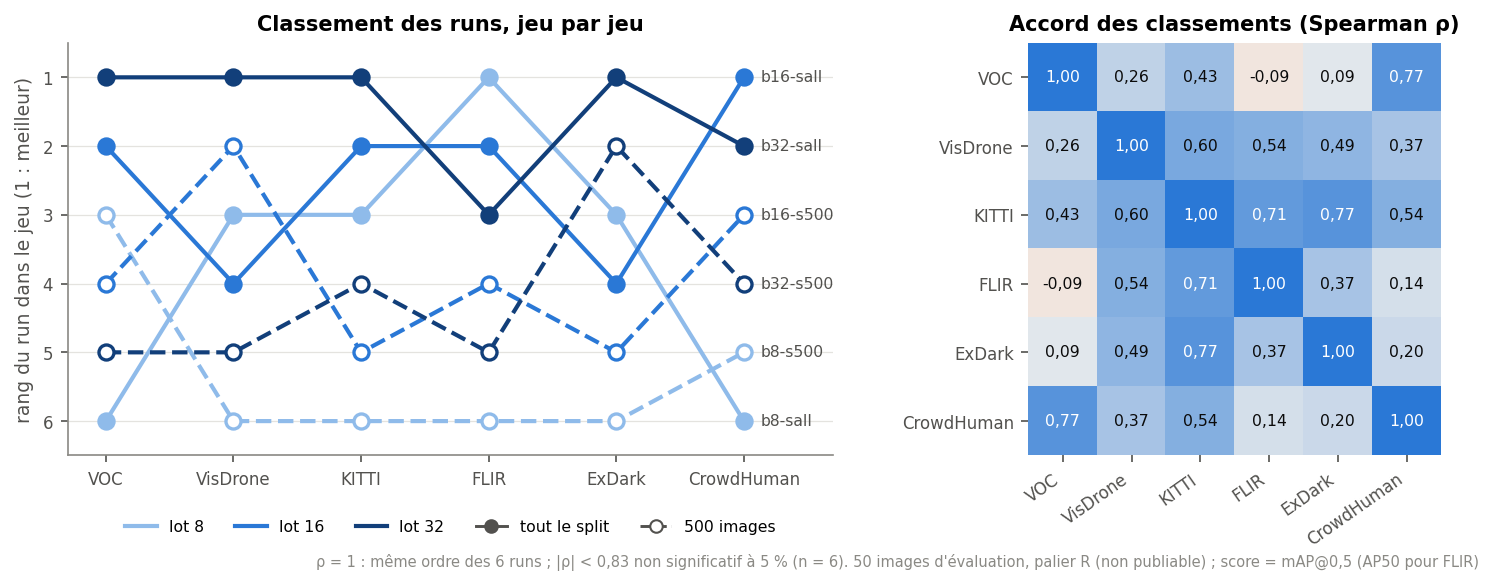

**Constat.** Spearman moyen entre jeux : 0,41. Classements les plus proches : VOC–CrowdHuman (0,77) ; les plus éloignés : VOC–FLIR (-0,09). Avec 6 runs, |ρ| < 0,83 n'est pas significatif à 5 %.

In [5]:
show(FB.PLOTS['classements'](data, OUT))
display(Markdown("**Constat.** " + OBS['classements']))

## 3. Effets principaux : sous-ensemble et lot

À gauche, chaque flèche va du run à 500 images (creux) au run sur tout le split (plein), à lot égal : une flèche vers la droite est un gain. À droite, le score relatif par lot, un point par jeu, et la moyenne sur les jeux (losanges). À 600 itérations, le lot fixe aussi le nombre d'images vues : lot et volume de données ne se séparent pas dans cette grille.

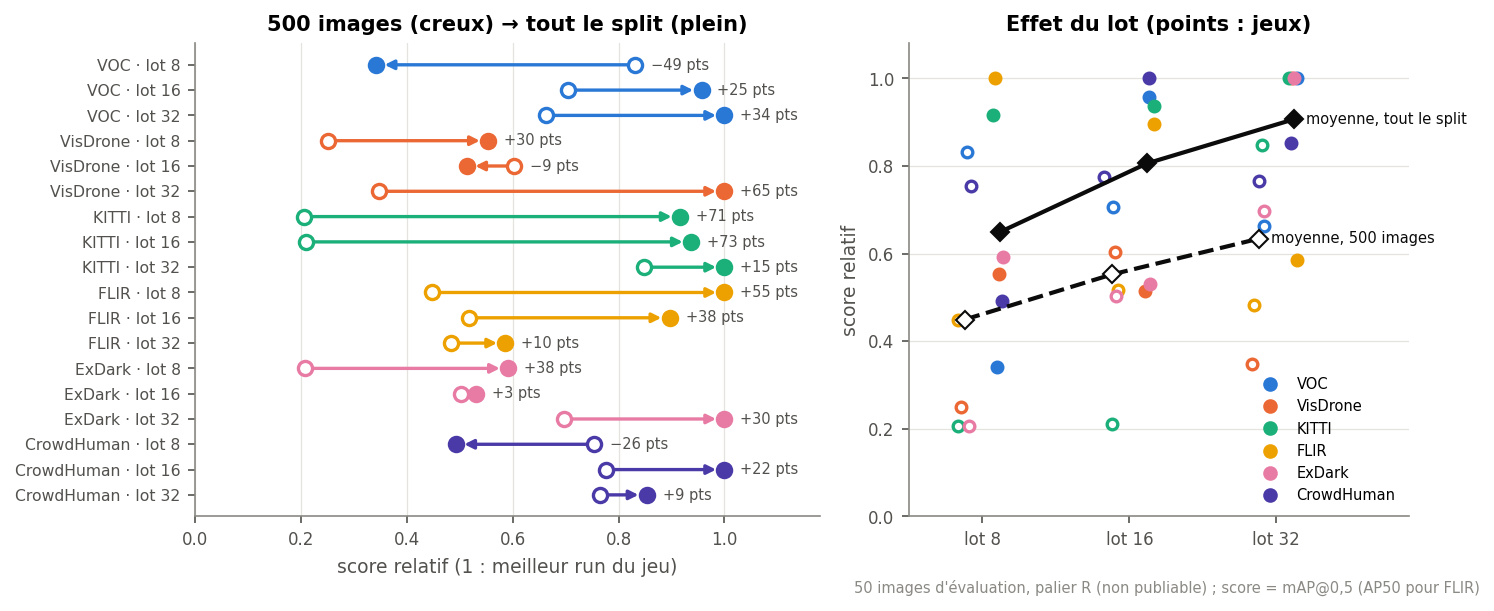

**Constat.** Tout le split bat 500 images dans 15 cas sur 18 (jeu × lot), de 0,24 en score relatif moyen. Score relatif moyen par lot : tout : lot 8 0,65, lot 16 0,81, lot 32 0,91 ; 500 images : lot 8 0,45, lot 16 0,55, lot 32 0,63.

In [6]:
show(FB.PLOTS['effets'](data, OUT))
display(Markdown("**Constat.** " + OBS['effets']))

## 4. Époques vues : voir plus d'images ou revoir les mêmes ?

L'axe horizontal compte les passages sur les données d'entraînement (lot × itérations / images, échelle log). Les runs sur tout le split (pleins) restent sous quelques époques ; ceux à 500 images (creux, zone grisée) revoient 10 à 38 fois les mêmes images. Si le score montait avec les époques seules, les deux nuages se prolongeraient ; un décrochage dans la zone grisée signe le surapprentissage.

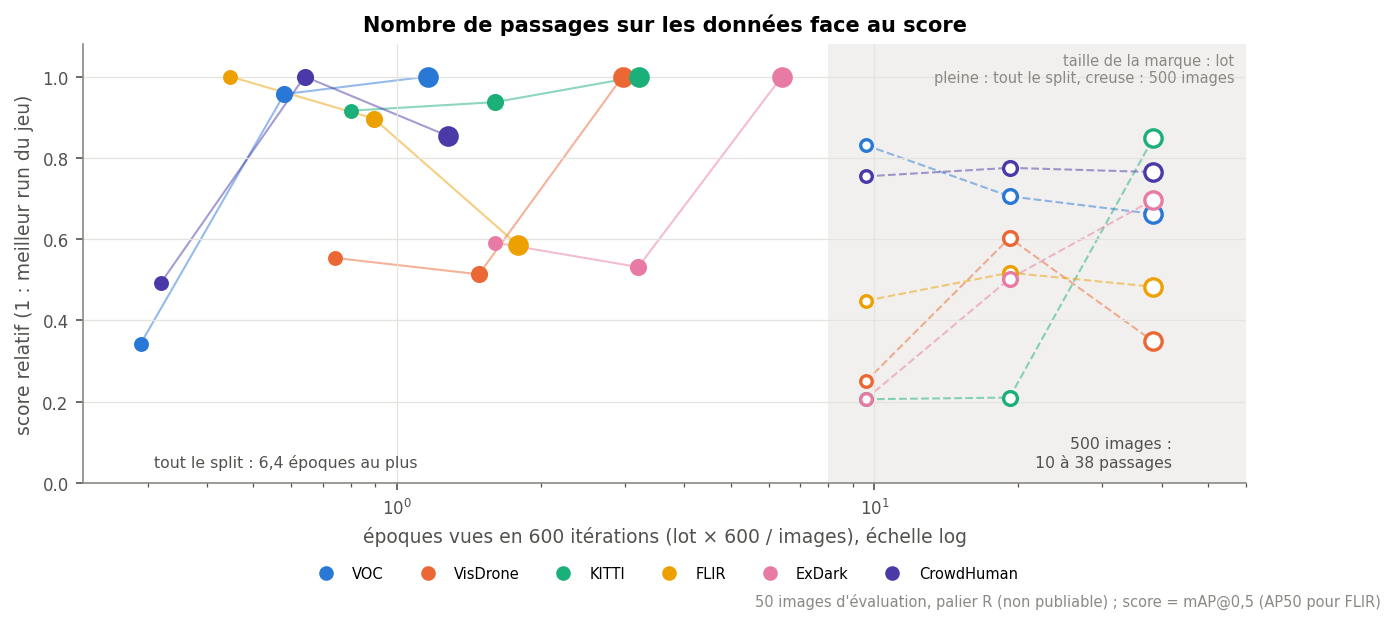

**Constat.** Corrélation de rangs entre époques vues et score relatif, tous jeux : -0,31. Les runs à 500 images font 9,6 à 38,4 époques ; ceux sur tout le split, 0,29 à 6,40. Score relatif moyen : 0,79 sur tout le split, 0,55 à 500 images.

In [7]:
show(FB.PLOTS['epoques'](data, OUT))
display(Markdown("**Constat.** " + OBS['epoques']))

## 5. Perte finale face au score

Un panneau par jeu (échelles propres). ρ est la corrélation de rangs entre perte finale et score : négative, la perte basse va avec le bon score ; proche de zéro ou positive, la perte ne prédit pas la mAP. Les runs à 500 images (creux) ont souvent les pertes les plus basses : ils ajustent un petit jeu, sans généraliser.

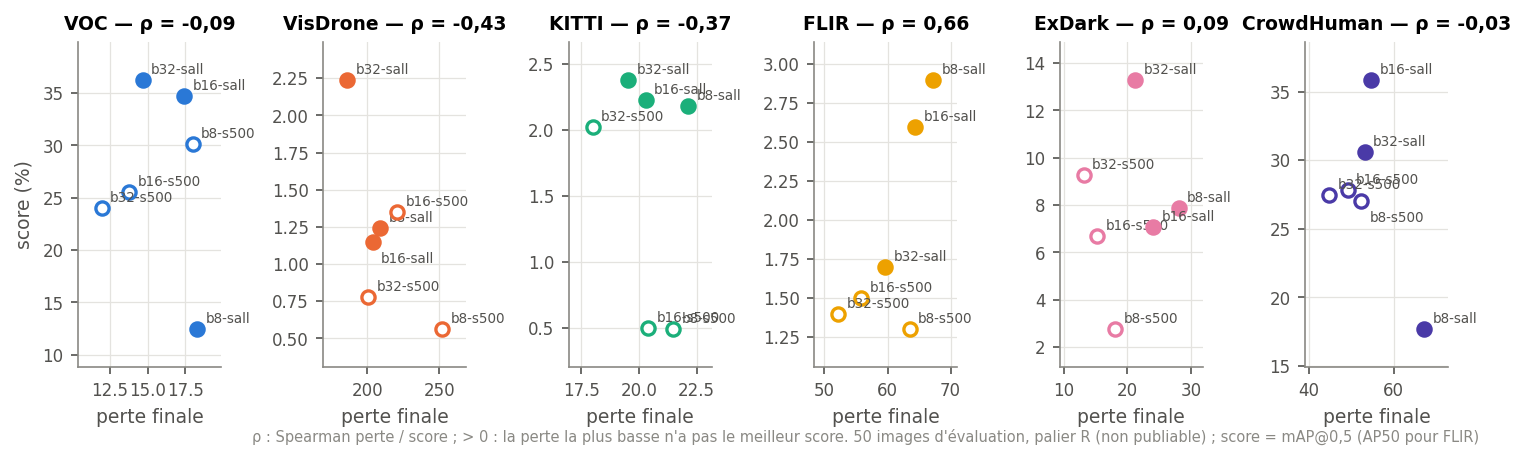

**Constat.** Corrélation de rangs perte finale / score, par jeu : VOC ρ = -0,09 (perte la plus basse : `b32-s500`, rang 5) ; VisDrone ρ = -0,43 (perte la plus basse : `b32-sall`, rang 1) ; KITTI ρ = -0,37 (perte la plus basse : `b32-s500`, rang 4) ; FLIR ρ = 0,66 (perte la plus basse : `b32-s500`, rang 5) ; ExDark ρ = 0,09 (perte la plus basse : `b32-s500`, rang 2) ; CrowdHuman ρ = -0,03 (perte la plus basse : `b32-s500`, rang 4). Une corrélation positive veut dire : plus la perte est basse, plus la mAP est basse (surapprentissage des runs à 500 images).

In [8]:
show(FB.PLOTS['perte'](data, OUT))
display(Markdown("**Constat.** " + OBS['perte']))

## 6. Courbes de perte

Perte d'entraînement lissée, une ligne par jeu (rangées) et par sous-ensemble (colonnes), une couleur par lot. La zone grisée est le burn-in : le taux d'apprentissage y monte de 0 à sa valeur, sur 500 des 600 itérations. Un run entraîné lors d'une session précédente n'a pas de journal dans le notebook : il est relu dans `build/notebooks/<jeu>/<modèle>/runs/<run>/loss.csv` après `make harvest` (récolte du Drive), sinon marqué « sans journal ».

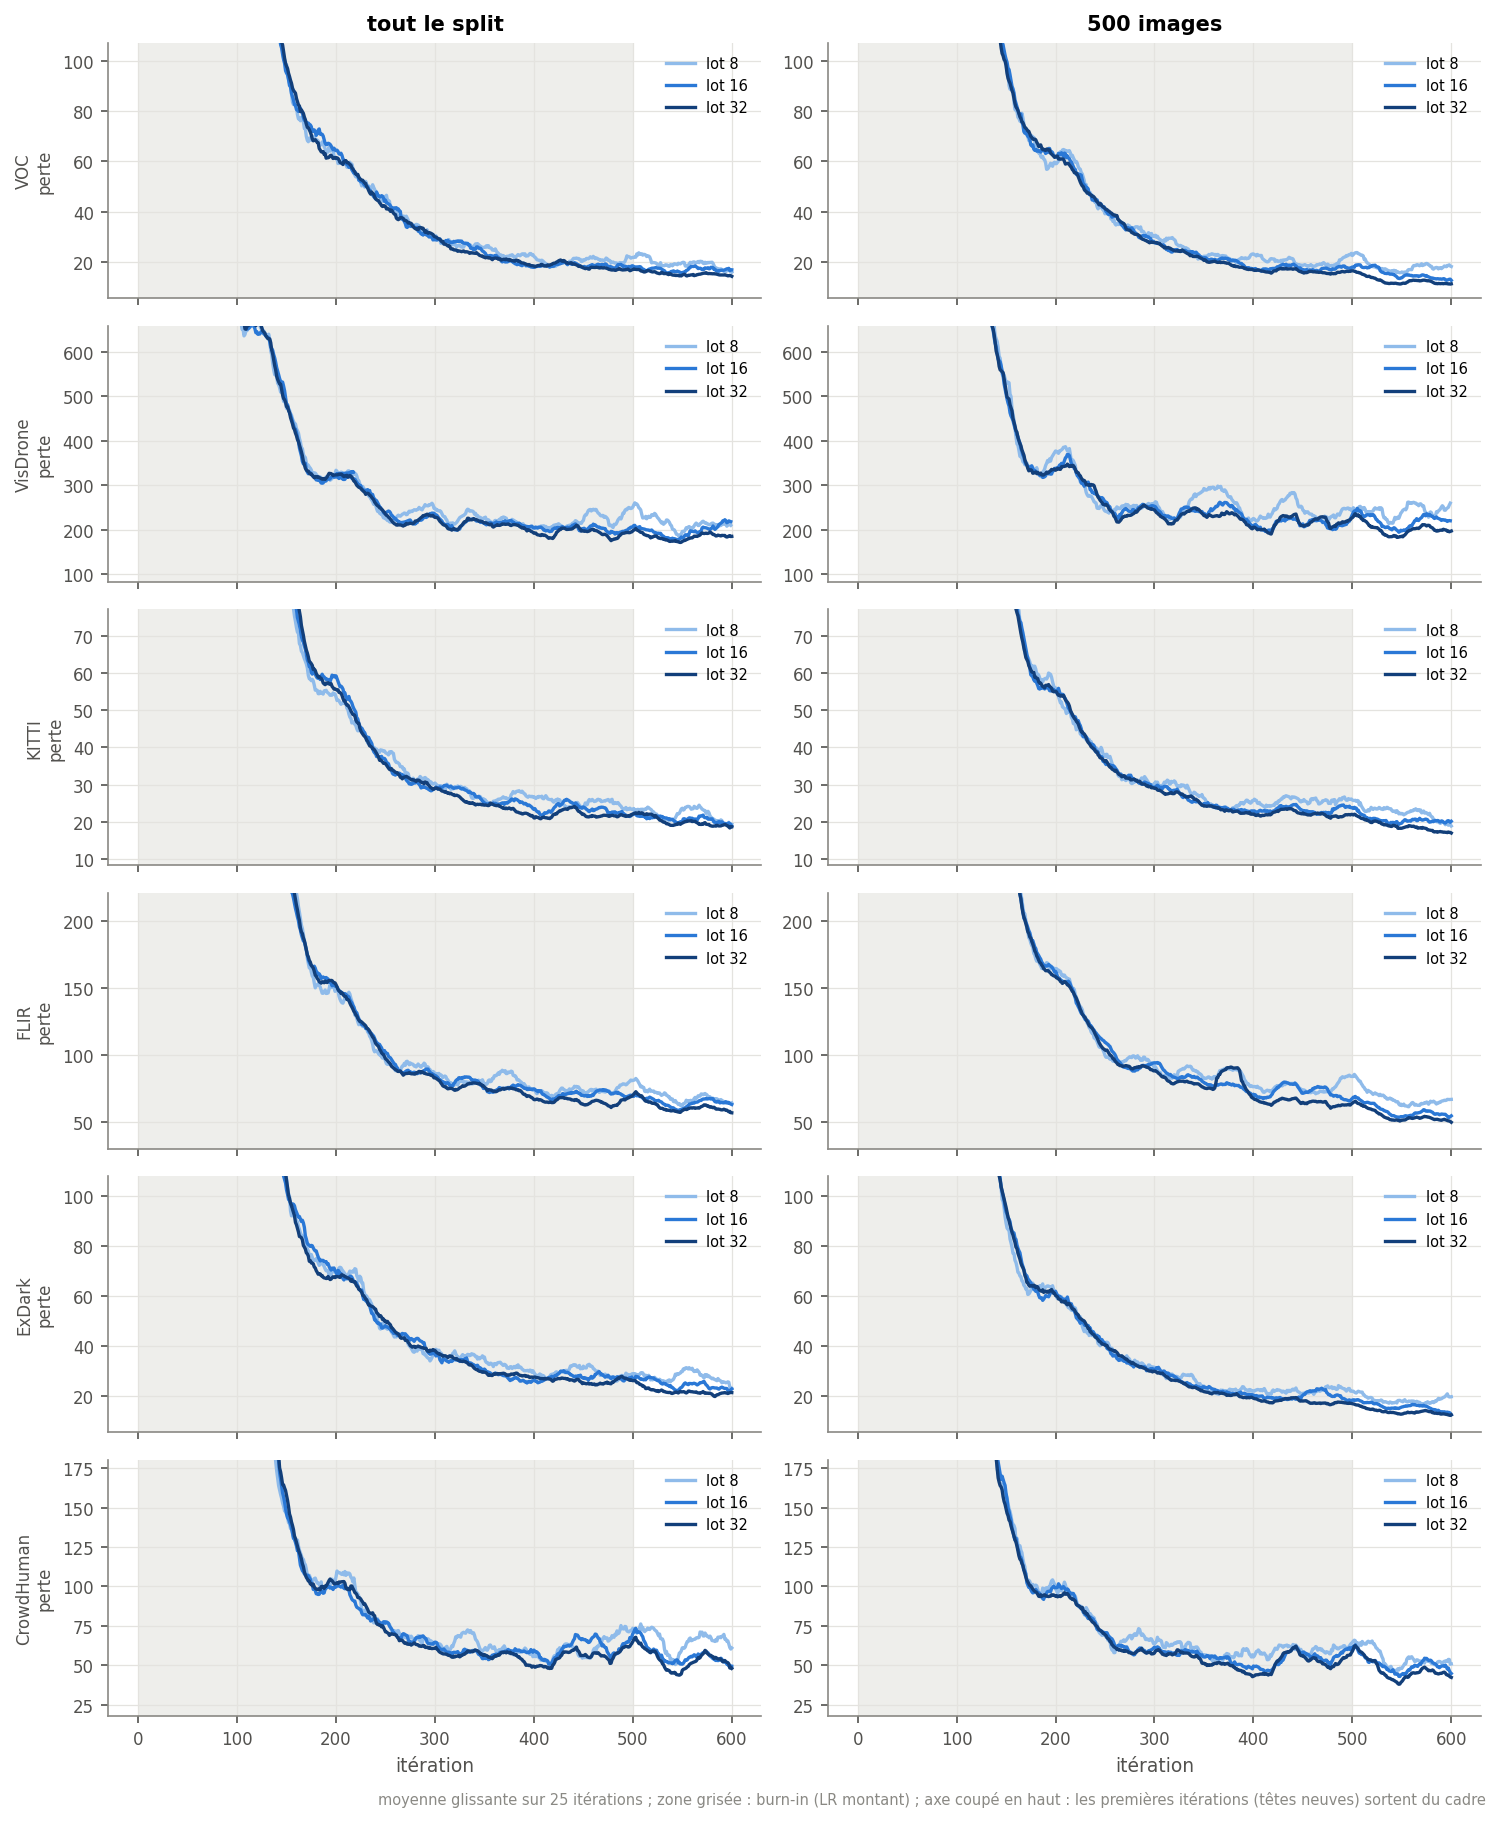

**Constat.** Les courbes des trois lots se superposent pendant l'essentiel du burn-in (LR montant en (it/burn-in)⁴ : moins de 20 % de sa valeur avant 66 % du burn-in) et ne s'écartent qu'à la fin. Perte finale du plus grand lot, en moins par rapport au plus petit (runs avec journal) : VOC 27 %, VisDrone 16 %, KITTI 14 %, FLIR 14 %, ExDark 26 %, CrowdHuman 18 %.

In [9]:
show(FB.PLOTS['courbes'](data, OUT, window=SMOOTH))
display(Markdown("**Constat.** " + OBS['courbes']))

## 7. De quoi est faite la perte finale ?

Part de chaque terme de la perte YOLO dans les 50 dernières itérations journalisées : coord (position et taille des boîtes), obj (confiance sur les objets), noobj (confiance sur le fond), cls (classes). Le chiffre à droite est la perte totale. Une part obj dominante dit que le réseau sait mal où sont les objets ; une part cls, qu'il les trouve mais les nomme mal.

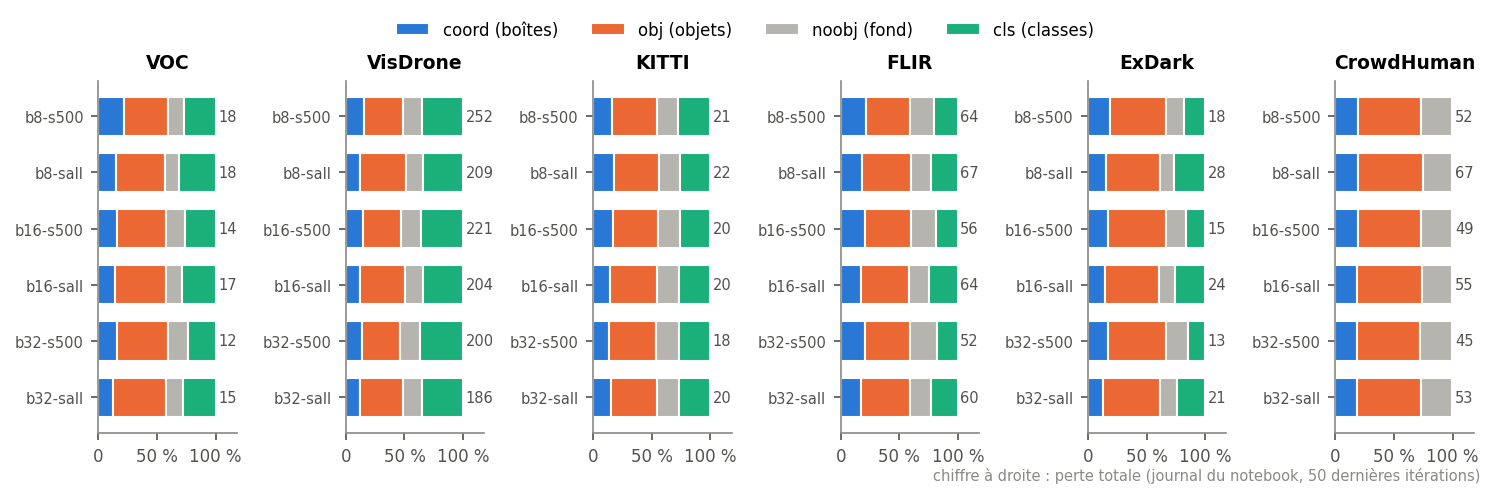

**Constat.** Terme dominant de la perte finale du meilleur run : VOC obj 45 %, VisDrone obj 37 %, KITTI obj 39 %, FLIR obj 42 %, ExDark obj 49 %, CrowdHuman obj 55 %.

In [10]:
show(FB.PLOTS['composantes'](data, OUT))
display(Markdown("**Constat.** " + OBS['composantes']))

## 8. AP par classe

AP@0,5 de chaque classe pour chaque run (runs triés du meilleur au moins bon). Les cases grises sont des classes sans instance dans les 50 images évaluées : leur AP n'existe pas, ce n'est pas un zéro. L'échelle de couleur est en racine carrée, pour distinguer les AP de 1 à 10. Une ligne pâle sur toute sa longueur est une classe qu'aucune configuration n'apprend en 600 itérations.

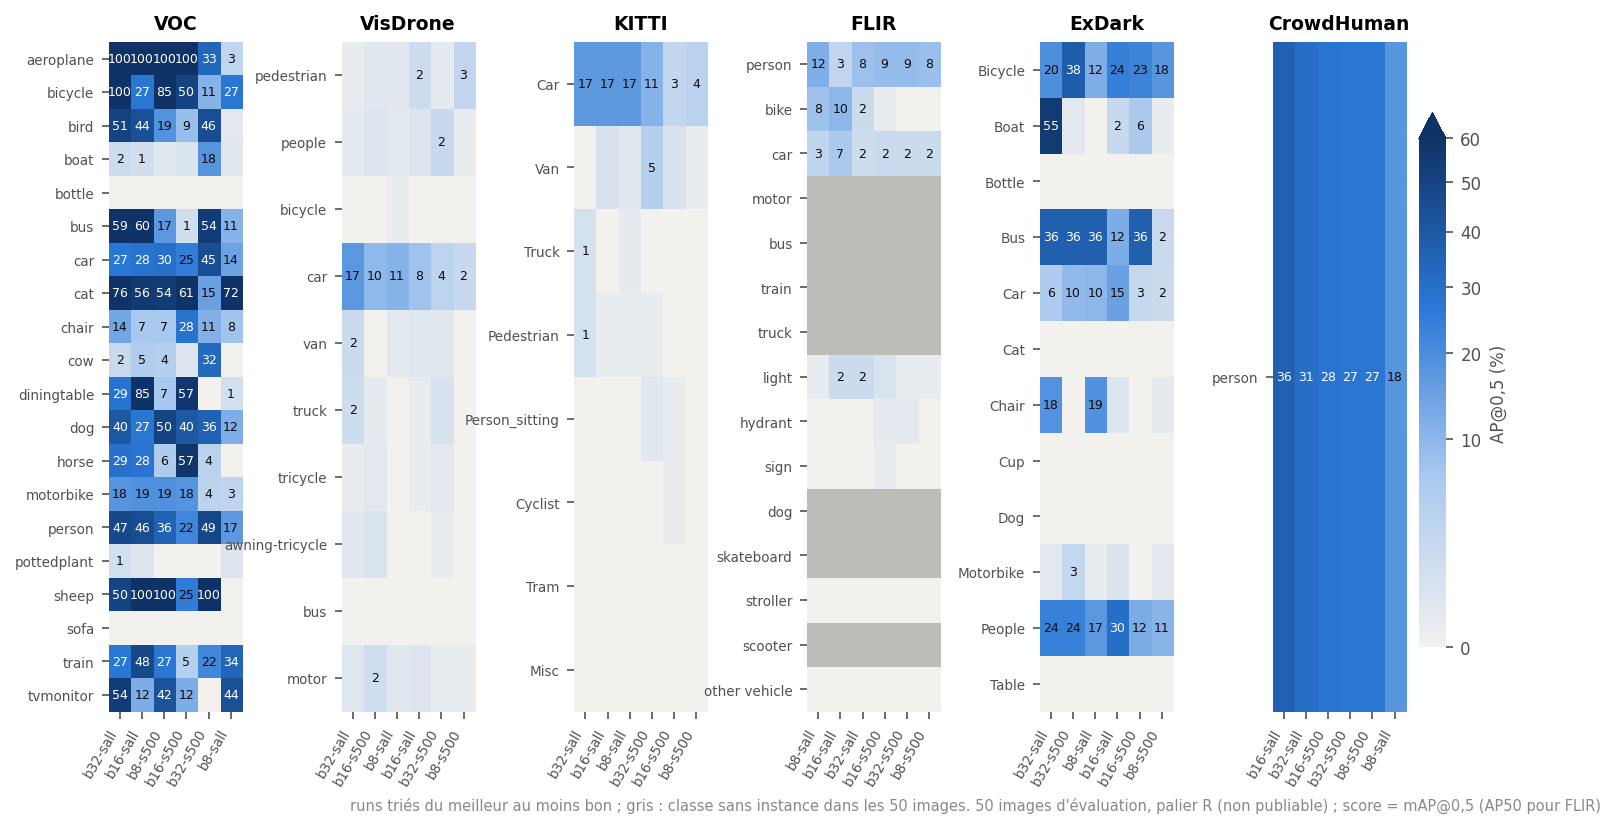

**Constat.** Classes présentes au-dessus de 5 points d'AP@0,5, meilleur run : VOC 15/20 (meilleure : aeroplane 100,0) ; VisDrone 1/10 (meilleure : car 17,4) ; KITTI 1/8 (meilleure : Car 16,8) ; FLIR 2/8 (meilleure : person 11,6) ; ExDark 6/12 (meilleure : Boat 55,3) ; CrowdHuman 1/1 (meilleure : person 35,9).

In [11]:
show(FB.PLOTS['classes'](data, OUT))
display(Markdown("**Constat.** " + OBS['classes']))

## 9. Affinage face aux poids publiés

Meilleur run affiné, et les poids Darknet publiés (Tiny-YOLOv3 COCO, Tiny-YOLOv2 VOC) lancés hors domaine sur les mêmes 50 images, chaque jeu à son échelle. Les poids publiés ne sont évalués que sur les classes qui ont un équivalent dans leurs classes (« n cl. », `MAPPINGS`) : leur score ne se compare au run affiné qu'à titre indicatif. Un run affiné sous les poids publiés dit qu'il manque des itérations.

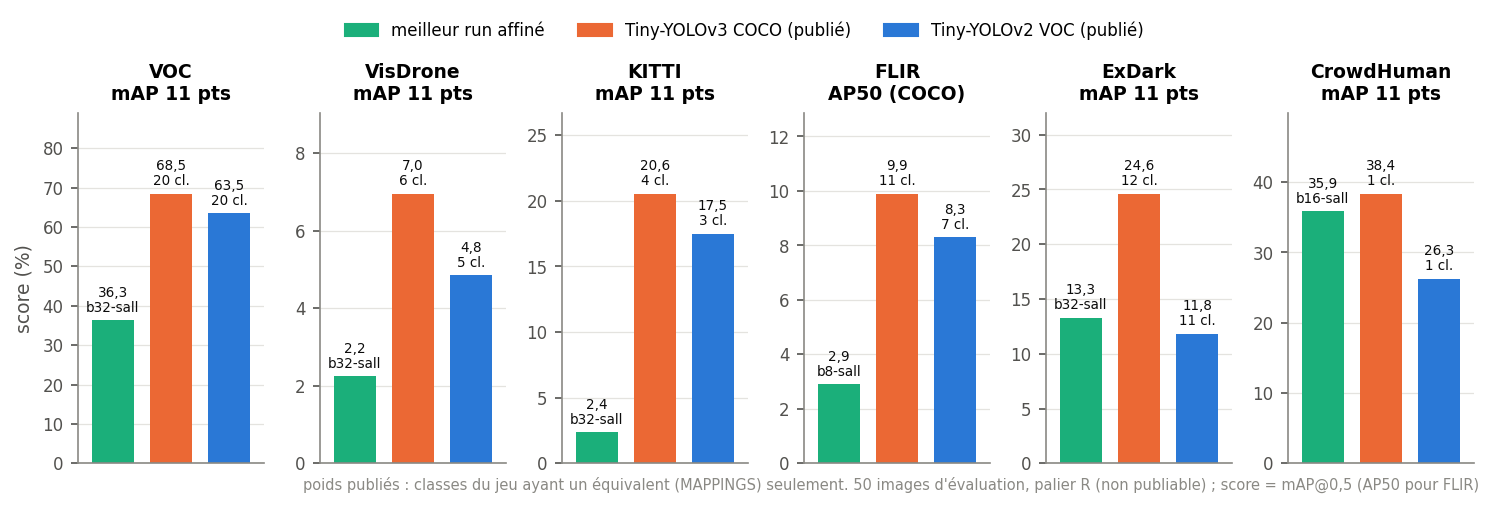

**Constat.** Meilleur run affiné face au meilleur poids publié : VOC 36,27 contre 68,45 (tiny-yolov3-coco, 20 classes évaluées) ; VisDrone 2,24 contre 6,95 (tiny-yolov3-coco, 6 classes évaluées) ; KITTI 2,38 contre 20,55 (tiny-yolov3-coco, 4 classes évaluées) ; FLIR 2,90 contre 9,90 (tiny-yolov3-coco, 11 classes évaluées) ; ExDark 13,29 contre 24,61 (tiny-yolov3-coco, 12 classes évaluées) ; CrowdHuman 35,87 contre 38,37 (tiny-yolov3-coco, 1 classes évaluées).

In [12]:
show(FB.PLOTS['publies'](data, OUT))
display(Markdown("**Constat.** " + OBS['publies']))

## 10. Coût d'un run

Durée d'un run de 600 itérations sur le GPU Colab face à son score relatif. La durée suit le lot (images traitées), pas le sous-ensemble. Durée : celle de la cellule, ou la somme de la colonne `seconds` de `loss.csv` pour un run complété depuis `build/`.

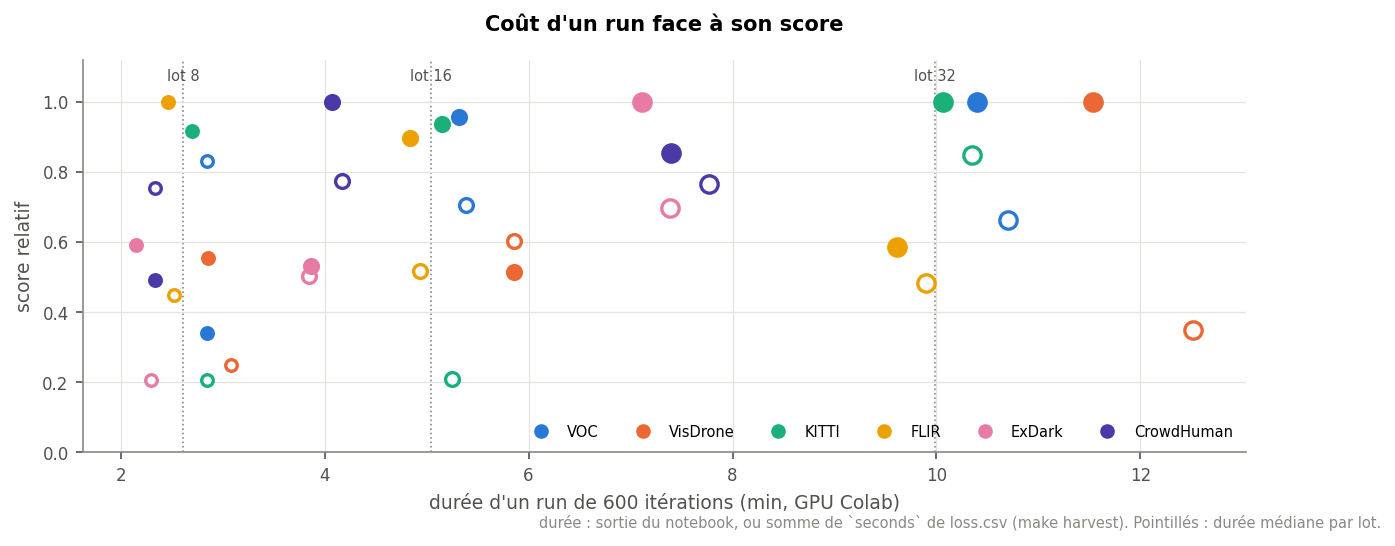

**Constat.** Durée moyenne d'un run de 600 itérations : lot 8 2,6 min, lot 16 4,9 min, lot 32 9,6 min.

In [13]:
show(FB.PLOTS['cout'](data, OUT))
display(Markdown("**Constat.** " + OBS['cout']))

## Conclusions

Calculées sur les balayages chargés ; elles se mettent à jour avec eux.

In [14]:
display(Markdown(B.conclusions(data, pending)))
print("commande équivalente :")
print(f"  python -m tools.notebooks.balayages --runs --json {OUT}/balayages.json")
print(f"  python -m tools.figures balayages  # PNG dans docs/tasks/figures/resultats/")

- **Configuration la plus robuste : `b32-sall`**, score relatif moyen 0,91 sur 6 jeux (meilleur run de 4 jeux).
- **Tout le split plutôt que 500 images** : gain moyen de 0,24 en score relatif (15 cas sur 18).
- **Affinage trop court** : le meilleur run reste sous les poids publiés hors domaine sur VOC (36,27 contre 68,45), VisDrone (2,24 contre 6,95), KITTI (2,38 contre 20,55), FLIR (2,90 contre 9,90), ExDark (13,29 contre 24,61), CrowdHuman (35,87 contre 38,37) ; 600 itérations (moins de 7 époques) ne suffisent pas à réapprendre les têtes.

commande équivalente :
  python -m tools.notebooks.balayages --runs --json build/notebooks/balayages/balayages.json
  python -m tools.figures balayages  # PNG dans docs/tasks/figures/resultats/
